In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy as scp
import sympy as sp
import pandas as pd  #biblioteca para puxar variáveis de tabelas e etc.
from IPython.display import display, Markdown
from numba import njit 

# Importando todas as funções do filtro de Kalman
from utils import *

# Configuração de estilo para os gráficos ficarem mais legíveis
plt.style.use('seaborn-v0_8-whitegrid')
# 1. Ativando o modo de impressão matemática elegante (LaTeX) no Jupyter
sp.init_printing()

# 1. Diagnóstico de falhas baseado em dados
## 1.1 Algorítmo do SVD (Decomposição de valores Singulares)

### Teoria matemática

Seja $A$ uma matriz real de dimensões $m \times n$. A Decomposição em Valores Singulares (SVD) estabelece que $A$ pode ser fatorada no produto de três matrizes específicas:

$$A = U \Sigma V^T$$

Onde os componentes são definidos da seguinte forma:

* **$U$**: É uma matriz ortogonal de dimensões $m \times m$. Suas colunas são chamadas de **vetores singulares à esquerda** de $A$. Por ser ortogonal, satisfaz a propriedade $U^T U = I$.
* **$\Sigma$**: É uma matriz retangular diagonal de dimensões $m \times n$. Os elementos da sua diagonal principal, denotados por $\sigma_i$, são os **valores singulares** de $A$. Eles são números reais e não negativos, dispostos em ordem decrescente: $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_r > 0$, onde $r$ é o posto (rank) da matriz $A$.
* **$V^T$**: É a transposta de uma matriz ortogonal $V$ de dimensões $n \times n$. As colunas de $V$ (linhas de $V^T$) são os **vetores singulares à direita** de $A$. Também satisfaz $V^T V = I$.

**Dedução por meio da Autodecomposição (Eigendecomposition)**

Como a matriz $A$ não é necessariamente quadrada, não podemos extrair seus autovalores diretamente. O SVD contorna isso operando sobre as matrizes quadradas e simétricas geradas por $A^T A$ e $A A^T$.

**1. Encontrando $V$ e $\Sigma$:**
Ao multiplicar $A$ pela sua transposta à esquerda, temos:

$$A^T A = (U \Sigma V^T)^T (U \Sigma V^T)$$

Aplicando a propriedade da transposta $(X Y)^T = Y^T X^T$:

$$A^T A = V \Sigma^T U^T U \Sigma V^T$$

Como $U$ é ortogonal, $U^T U = I$. A equação é simplificada para:

$$A^T A = V (\Sigma^T \Sigma) V^T$$
$$A^T A = V \Sigma^2 V^T$$

Essa equação final tem a forma exata da decomposição espectral $M = Q \Lambda Q^{-1}$. Portanto:
* A matriz $V$ é formada pelos **autovetores** ortonormais de $A^T A$.
* A matriz $\Sigma^2$ contém os **autovalores** ($\lambda_i$) de $A^T A$. Logo, os valores singulares são dados por $\sigma_i = \sqrt{\lambda_i}$.

**2. Encontrando $U$:**
O mesmo princípio é aplicado operando a multiplicação à direita:

$$A A^T = (U \Sigma V^T) (U \Sigma V^T)^T$$
$$A A^T = U \Sigma V^T V \Sigma^T U^T$$

Como $V^T V = I$:

$$A A^T = U (\Sigma \Sigma^T) U^T$$
$$A A^T = U \Sigma^2 U^T$$

Assim, conclui-se que a matriz $U$ é formada pelos **autovetores** ortonormais da matriz simétrica $A A^T$. 

**Forma de Somatório (Expansão de Posto Reduzido)**

A operação matricial $A = U \Sigma V^T$ também pode ser expressa como uma soma ponderada de matrizes de posto 1 (produtos externos entre os vetores singulares), o que é a base matemática para métodos de redução de dimensionalidade:

$$A = \sum_{i=1}^{r} \sigma_i u_i v_i^T$$

Onde $r$ é o posto da matriz $A$, $u_i$ é a $i$-ésima coluna de $U$, e $v_i^T$ é a $i$-ésima linha de $V^T$.

Matriz $\mathbf{A}$:

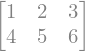

### 1. Gabarito: SVD nativo do NumPy

**$U$:**

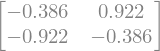

**$V^T$:**

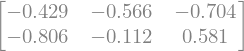

---

### 2. SVD construído  pela Teoria

**$U$ (Calculado via $A v_i = \sigma_i u_i$):**

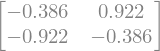

**$V^T$ (Autovetores truncados e ordenados de $A^T A$):**

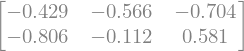

---

### 3. Reconstrução da Matriz A para provar que funciona:

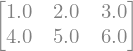

In [3]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

display(Markdown("Matriz $\mathbf{A}$:"),sp.Matrix(A))

U_svd, S_array, VT_svd = np.linalg.svd(A, full_matrices=False)

display(Markdown("### 1. Gabarito: SVD nativo do NumPy"))
display(Markdown("**$U$:**"), sp.Matrix(np.round(U_svd, 3)))
display(Markdown("**$V^T$:**"), sp.Matrix(np.round(VT_svd, 3)))


display(Markdown("---"))
display(Markdown("### 2. SVD construído  pela Teoria"))

# Calcular autovalores e autovetores apenas de A^T * A
ATA = A.T @ A 
autovalores, autovetores_V = np.linalg.eigh(ATA)

# Inverter a ordem para decrescente (do maior pro menor)
autovalores = autovalores[::-1]
autovetores_V = autovetores_V[:, ::-1]

# O posto da matriz é 2. Pegamos apenas os 2 maiores autovalores e vetores
sigma = np.sqrt(autovalores[:2])
V_teoria = autovetores_V[:, :2]

# Para bater visualmente idêntico no Jupyter, alinhamos nossos vetores com a escolha do NumPy:
for i in range(2):
    if np.sign(V_teoria[0, i]) != np.sign(VT_svd.T[0, i]):
        V_teoria[:, i] *= -1

# Em vez de calcular o eigh de A A^T, usamos a amarra: U = (A * V) / sigma
U_teoria = np.zeros((2, 2))
for i in range(2):
    U_teoria[:, i] = (A @ V_teoria[:, i]) / sigma[i]


# Exibindo os resultados provados na mão
VT_teoria = V_teoria.T # Transpondo o V para virar V^T

display(Markdown("**$U$ (Calculado via $A v_i = \sigma_i u_i$):**"))
display(sp.Matrix(np.round(U_teoria, 3)))

display(Markdown("**$V^T$ (Autovetores truncados e ordenados de $A^T A$):**"))
display(sp.Matrix(np.round(VT_teoria, 3)))

display(Markdown("---"))
display(Markdown("### 3. Reconstrução da Matriz A para provar que funciona:"))

# Reconstruindo A = U * Sigma * V^T
S_matriz = np.diag(sigma)
A_reconstruida = U_teoria @ S_matriz @ VT_teoria

display(sp.Matrix(np.round(A_reconstruida, 3)))

### Interpretação Geométrica: Rotações e Escalonamento

O poder intuitivo do SVD reside na sua interpretação geométrica. A decomposição $A = U \Sigma V^T$ demonstra que qualquer transformação linear complexa, representada por uma matriz $A$, pode ser quebrada em uma sequência de três operações geométricas simples e perfeitamente separáveis: uma rotação, um escalonamento e outra rotação.

Ao aplicarmos a matriz $A$ a um vetor $x$ (ou seja, calcularmos $Ax$), o vetor passa pelas seguintes transformações lidas da direita para a esquerda:

* **1. Rotação inicial ($V^T$):** O vetor $x$ é primeiramente multiplicado por $V^T$. Como $V^T$ é uma matriz ortogonal, ela atua como uma transformação isométrica. Isso significa que ela **rotaciona** (ou reflete) o sistema de coordenadas de entrada sem alterar o comprimento do vetor original.
* **2. Escalonamento ($\Sigma$):** Em seguida, a matriz diagonal $\Sigma$ entra em ação. Ela **estica ou comprime** o espaço ao longo dos novos eixos de coordenadas. A magnitude desse estiramento em cada direção é ditada exatamente pelos valores singulares $\sigma_i$. Se um valor singular for zero, aquela dimensão específica entra em colapso.
* **3. Rotação final ($U$):** Por fim, a matriz ortogonal $U$ aplica uma nova **rotação** (ou reflexão) aos dados. Esta etapa alinha os eixos recém-esticados para a sua orientação definitiva no espaço dgulares à direita**).

### Importância, Aplicações e Técnicas Derivadas

A Decomposição em Valores Singulares é frequentemente chamada de "canivete suíço da álgebra linear" devido à sua universalidade e estabilidade numérica. Ao contrário de outras fatorações, o SVD garante uma solução para **qualquer** matriz, seja ela quadrada, retangular, singular ou cheia de ruído. 

Sua importância teórica atinge o ápice com o **Teorema de Eckart-Young-Mirsky**, que prova que truncar o SVD (ou seja, manter apenas os maiores valores singulares) fornece a **melhor aproximação matemática possível** de uma matriz original para um dado posto (rank) reduzido.

#### O que é possível fazer com o SVD?

Ao isolar a "energia" de um sistema numérico nos maiores valores singulares ($\sigma_i$), o SVD destrava diversas aplicações fundamentais:

* **Compressão de Dados e Imagens:** Uma imagem digital pode ser vista como uma matriz de pixels. Armazenando apenas as primeiras dezenas de vetores de $U$, $V^T$ e os maiores $\sigma_i$, é possível reconstruir a imagem visualmente intacta ocupando uma fração minúscula do espaço de armazenamento original.

* **Filtragem de Ruídos:** Em sinais ou dados experimentais, a informação principal geralmente se concentra nos maiores valores singulares, enquanto o ruído aleatório se espalha pelos menores. Zerar esses valores menores elimina o ruído sem distorcer o sinal original.
* **Resolução de Sistemas Lineares (Pseudo-inversa):** Para sistemas onde a matriz não tem inversa (sistemas sobredeterminados ou subdeterminados, comuns em Mínimos Quadrados), o SVD permite calcular a pseudo-inversa de Moore-Penrose ($A^+$). Ela é dada por $A^+ = V \Sigma^+ U^T$, onde $\Sigma^+$ inverte os $\sigma_i$ não nulos. Isso garante a solução de menor erro possível para $Ax = b$.
* **Sistemas de Recomendação:** Empresas como Netflix e Amazon utilizam o SVD (ou variantes iterativas) em matrizes esparsas de usuários $\times$ produtos. O algoritmo preenche os "buracos" da matriz, prevendo a nota que um usuário daria a um filme que ainda não assistiu.

#### Técnicas e Algoritmos Derivados

O sucesso do SVD inspirou e embasou o desenvolvimento de diversas outras técnicas avançadas em estatística, ciência de dados e engenharia:

1.  **PCA (Análise de Componentes Principais):** A técnica mais famosa de redução de dimensionalidade em Machine Learning é, matematicamente, uma aplicação direta do SVD. Quando você centraliza as colunas de uma matriz de dados na média e aplica o SVD, os vetores singulares à direita ($V^T$) são exatamente as **Componentes Principais**, e os valores singulares indicam a variância capturada por cada componente.
2.  **LSA / LSI (Análise Semântica Latente):** No Processamento de Linguagem Natural (NLP), o SVD é aplicado a uma matriz de termos $\times$ documentos. Ele é capaz de derivar o "conceito" ou a "semântica" oculta por trás das palavras, agrupando sinônimos e permitindo que algoritmos entendam o contexto de um texto.
3.  **Truncated SVD e Randomized SVD:** Em cenários de Big Data, calcular o SVD completo de uma matriz gigantesca é inviável computacionalmente. Essas técnicas derivadas utilizam métodos probabilísticos para calcular apenas os primeiros $k$ valores singulares de forma extremamente rápida, com uma perda de precisão quase insignificante.
4.  **POD (Decomposição Ortogonal Própria):** Na engenharia mecânica e aeroespacial, o SVD é aplicado sob o nome de POD para extrair os "modos dominantes" do comportamento de fluidos (como o fluxo de ar ao redor de uma asa de avião) ou da vibração de estruturas complexas.

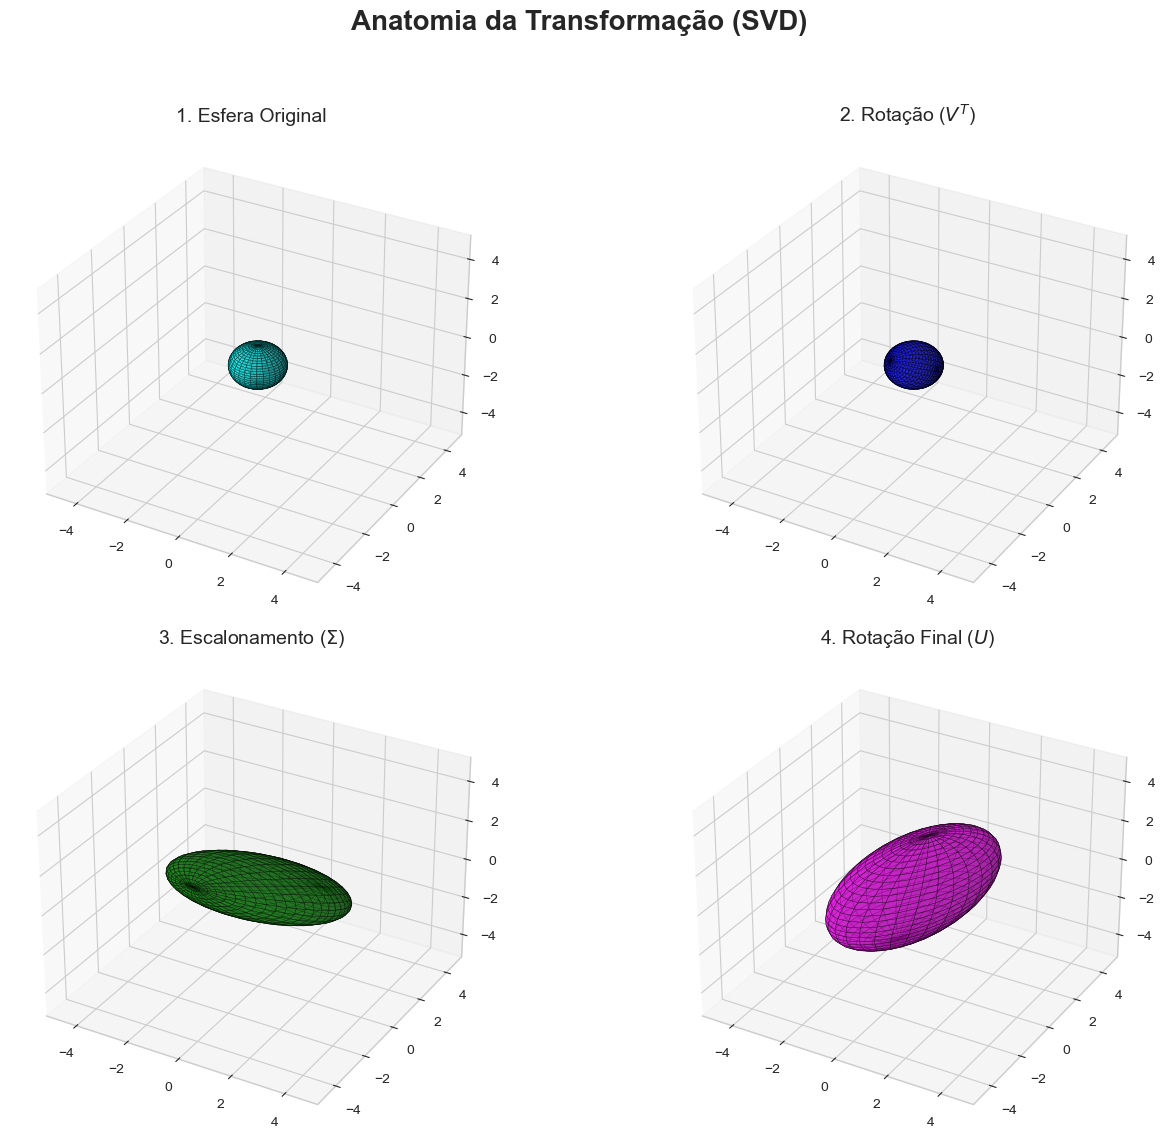

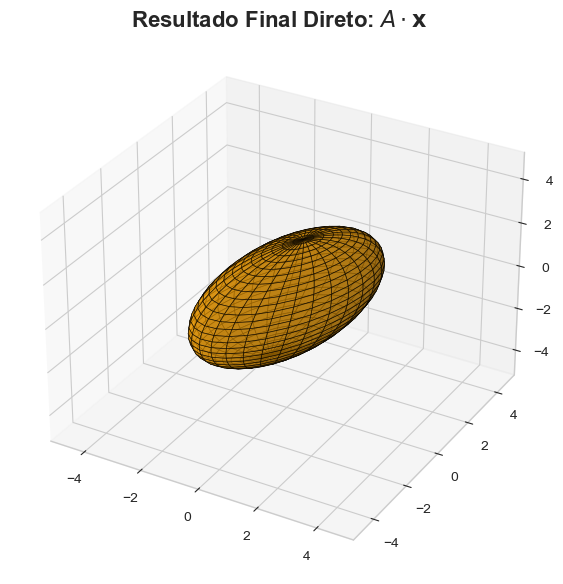

In [4]:
n = 30
theta = np.linspace(0, 2*np.pi, n)
phi = np.linspace(0, np.pi, n)

x = np.outer(np.cos(theta), np.sin(phi)) 
y = np.outer(np.sin(theta), np.sin(phi))
z = np.outer(np.ones(np.size(theta)), np.cos(phi))
pontos_original = np.vstack((x.flatten(), y.flatten(), z.flatten()))

# --- 2. Matriz e SVD ---
A = np.array([[2, 1, 0],
              [1, 2, 1],
              [0, 1, 2]])

U, S_array, VT = np.linalg.svd(A)
S = np.diag(S_array)

# Etapas
p0 = pontos_original  # Original
p1 = VT @ p0         # Rotação VT
p2 = S @ p1          # Estiramento Sigma
p3 = U @ p2          # Rotação Final U
p_final = A @ p0     # Operação Direta

# --- 3. FIGURA 1: Decomposição SVD (2x2) ---
fig1 = plt.figure(figsize=(14, 12))
fig1.suptitle('Anatomia da Transformação (SVD)', fontsize=20, fontweight='bold')

titulos_svd = ["1. Esfera Original", "2. Rotação ($V^T$)", 
               "3. Escalonamento ($\Sigma$)", "4. Rotação Final ($U$)"]
etapas_svd = [p0, p1, p2, p3]
cores_svd = ['cyan', 'blue', 'green', 'magenta']

for i in range(4):
    ax = fig1.add_subplot(2, 2, i+1, projection='3d')
    X = etapas_svd[i][0, :].reshape(x.shape)
    Y = etapas_svd[i][1, :].reshape(y.shape)
    Z = etapas_svd[i][2, :].reshape(z.shape)
    
    ax.plot_surface(X, Y, Z, color=cores_svd[i], alpha=0.6, edgecolor='black', linewidth=0.3)
    ax.set_title(titulos_svd[i], fontsize=14)
    
    lim = 5
    ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# --- 4. FIGURA 2: Operação Completa (Fora) ---
fig2 = plt.figure(figsize=(8, 7))
ax_f = fig2.add_subplot(111, projection='3d')

X_f = p_final[0, :].reshape(x.shape)
Y_f = p_final[1, :].reshape(y.shape)
Z_f = p_final[2, :].reshape(z.shape)

ax_f.plot_surface(X_f, Y_f, Z_f, color='orange', alpha=0.7, edgecolor='black', linewidth=0.5)
ax_f.set_title("Resultado Final Direto: $A \cdot \mathbf{x}$", fontsize=16, fontweight='bold')

ax_f.set_xlim([-lim, lim]); ax_f.set_ylim([-lim, lim]); ax_f.set_zlim([-lim, lim])

plt.show()



### Matriz de Hankel: Definição e Lógica de Cálculo

Uma **Matriz de Hankel** é estruturada de forma que todas as suas diagonais ascendentes (da esquerda para a direita) possuem valores constantes. 

Matematicamente, o valor de qualquer elemento $h_{i,j}$ depende exclusivamente da soma do seu índice de linha $i$ com o seu índice de coluna $j$.

#### A Lógica de Construção (Embedding)

Para construir uma matriz de Hankel a partir de uma série temporal $Y = (y_1, y_2, \dots, y_N)$, você precisa definir o **comprimento da janela** $L$ (que será o número de linhas da matriz). 

O número de colunas $K$ será determinado pela fórmula:
$$K = N - L + 1$$

O preenchimento da matriz $X$ de dimensões $L \times K$ segue a seguinte regra de cálculo para cada elemento:

$$h_{i,j} = y_{i+j-1}$$

Sendo $i \in \{1, 2, \dots, L\}$ e $j \in \{1, 2, \dots, K\}$.

#### Estrutura Visual do Resultado

Ao iterar com a regra acima, sua função deve gerar a seguinte estrutura, onde cada coluna é um "deslizamento" da janela sobre os dados originais:

$$
X = \begin{bmatrix} 
y_1 & y_2 & y_3 & \dots & y_K \\
y_2 & y_3 & y_4 & \dots & y_{K+1} \\
y_3 & y_4 & y_5 & \dots & y_{K+2} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
y_L & y_{L+1} & y_{L+2} & \dots & y_N 
\end{bmatrix}
$$

In [5]:
#Definir funções compiladas em C (Numba)
@njit(fastmath=True)
def _build_numba(Y,L,K):
    """Constrói matrizes de Henkel na velocidade do C."""
    X= np.zeros((L,K))
    for i in range(L):
        for j in range(K):
            X[i,j]=Y[i+j]

    return X
    
@njit(fastmath=True)
def _sum_diag_numba(X,k):
    """ Soma os elementos de uma antidiagonal específcia (i+j=k)."""
    L,K = X.shape
    soma = 0.0
    inicio = max(0,k-K+1)
    fim = min(k,L-1)

    for i in range(inicio, fim+1):
        soma +=X[i,k-i]

    return soma 


@njit(fastmath=True)
def _num_diag_numba(k,L,K):
    """
    Retorna o número de elementos na antidiagonal k.
    Fórmula exata para O(1) de processamento
    """
    L_star = min(L,K)
    K_star = max(L,K)
    N = L+K-1

    if k<L_star -1:
        return k+1
    elif k < K_star:
        return L_star
    else:
        return N-k

@njit(fastmath=True)
def _reconstruct_numba(X,L,K):
    """
    Realiza a etapa 4 do SSA (Média Diagonal) na velocidade do C.
    Itera sobre todas as antidiagonais para reconstruir a série 1D.
    """
    N = L + K - 1
    Y_reconstruido = np.zeros(N)

    for k in range(N):
        # Reutilizamos as funções hiper-rápidas que você já criou
        soma = _sum_diag_numba(X, k)
        elementos = _num_diag_numba(k, L, K)
        
        # Calcula a média daquela diagonal e salva no vetor final
        Y_reconstruido[k] = soma / elementos

    return Y_reconstruido

#=
# Classe para encapsular tudo
class Hankel:
    def __init__(self, Y,L):
        """
        Inicializo a classe para gerar a matriz de Henkel
        """
        self.Y = np.asarray(Y, dtype=np.float64)
        self.L = L
        self.N = len(self.Y)
        self.K = self.N - self.L +1 
        if self.K <= 0:
            raise ValueError("O tamanho da janela L não pode ser maior que o tamanho da série N")
            
        # Chama a função otimizada
        self.X = _build_numba(self.Y, self.L, self.K)
                
    def sum_diag(self, n_diag):
        """Retorna a soma de elementos na diagonal requisitada (n_diag vai de 0 até N-1)."""
        return _sum_diag_numba(self.X, n_diag)

    def num_diag(self, n_diag):
        """Retorna o número de elementos na diagonal considerada."""
        return _num_diag_numba(n_diag, self.L, self.K)

    def reconstruct(self, X_modificada=None):
        """
        Reconstrói a série temporal a partir de uma matriz usando a média diagonal.
        
        Parâmetros:
        -----------
        X_modificada : np.ndarray, opcional
            Matriz filtrada (ex: sem o ruído). Se não for fornecida, 
            o método testa a reconstrução da matriz original (self.X).
            
        Retornos:
        ---------
        np.ndarray
            A série temporal 1D reconstruída.
        """
        # Se o usuário passou a matriz limpa, usamos ela. Se não, usamos a original.
        if X_modificada is not None:
            matriz_alvo = np.asarray(X_modificada, dtype=np.float64)
            # Verifica se as dimensões batem com a janela original
            if matriz_alvo.shape != (self.L, self.K):
                raise ValueError(f"A matriz modificada deve ter shape ({self.L}, {self.K})")
        else:
            matriz_alvo = self.X
            
        return _reconstruct_numba(matriz_alvo, self.L, self.K)

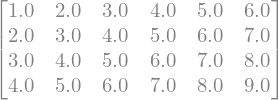

Soma da diagonal 2: 20.0
Qtd elementos diagonal 2: 3


In [6]:
serie = np.arange(1, 10)  # [1, 2, 3, 4, 5, 6, 7]
H = Hankel(serie, L=4)

H_sym = sp.Matrix(H.X)
display(H_sym)
print(f"Soma da diagonal 2: {H.sum_diag(4)}")
print(f"Qtd elementos diagonal 2: {H.num_diag(2)}")

## 1.2 Singular Spectrum Analysis (SSA)

A **Análise de Espectro Singular (SSA)** é uma técnica não-paramétrica de análise de séries temporais ue combina elementos de estatística, análise multivariada e álgebra linear. Seu objetivo é decompor uma série em componentes interpretáveis (tendência, oscilações e ruído).

### 1. Matemática e Decomposição
Dada uma série temporal $Y = (y_1, \dots, y_N)$, a análise segue quatro passos principais:



,XML0,XML1,XML2,XML3,XML4,XML5,XML6,XML7,XML8,XML9,...,XML42,XML43,XML44,XML45,XML46,XML47,XML48,XML49,XML50,XML51
0,0.25025,3657.2,4520.1,9.3965,26.715,42.191,2704.5,74.593,120.42,0.33701,...,53.850,24.670,61.839,22.101,40.078,33.041,48.969,47.459,41.841,18.049
1,0.25135,3662.1,4532.3,9.4020,26.644,42.812,2704.9,75.044,120.39,0.33723,...,53.705,24.562,61.348,22.264,40.050,39.154,49.870,47.403,41.188,18.008
2,0.25045,3681.9,4493.6,9.2395,26.971,42.282,2705.0,75.405,120.42,0.33643,...,54.167,24.659,61.826,22.312,40.147,39.294,44.511,47.265,41.290,18.009
3,0.25056,3667.9,4466.0,9.3602,26.937,42.194,2705.9,75.397,120.41,0.33891,...,54.498,24.648,63.168,22.288,39.845,36.334,46.168,47.410,40.997,17.771
4,0.28659,3693.0,4502.5,9.5652,26.999,42.540,2704.3,74.749,120.39,0.34173,...,54.142,28.430,57.566,22.142,40.806,34.882,45.576,47.424,41.290,19.371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,0.75426,3656.7,4536.1,8.8068,26.724,42.227,2700.9,74.242,120.39,0.28932,...,53.348,74.398,56.728,22.327,34.240,37.948,45.863,63.912,40.938,16.964
956,0.75962,3650.0,4459.2,8.8456,27.054,42.361,2701.4,75.182,120.41,0.29400,...,54.261,75.030,58.422,22.548,34.863,38.509,44.698,64.087,42.010,16.724
957,0.75920,3625.5,4501.2,8.8241,26.976,42.511,2704.0,75.614,120.40,0.29359,...,53.758,75.071,57.035,22.941,34.912,36.447,42.824,64.318,40.789,17.699
958,0.78204,3634.0,4508.1,8.8987,27.286,42.300,2702.0,74.805,120.39,0.33121,...,54.191,77.323,57.030,22.481,39.768,30.297,44.762,64.357,41.169,19.572


(960,)


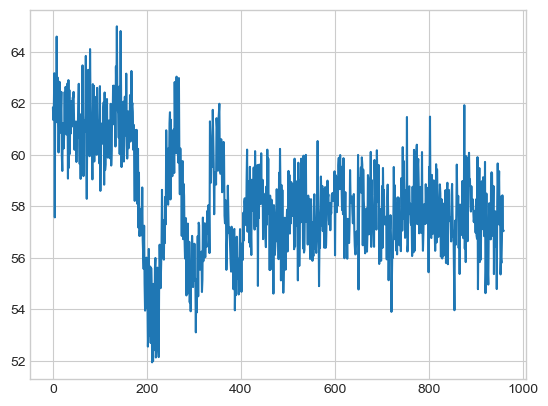

In [44]:
#Nome das Colunas
colums = [f"XML{i}" for i in range(52)]

# Puxar uma série temporal com pandas para testar
df = pd.read_csv('TE_process/d01_te.dat', sep='\s+', header=None,names=colums)

# Exibindo o elemento correspondente da tabela
display(df)

# Puxando a Série temporal
serie = np.array(df["XML44"], dtype=np.float64) #960 colunas

# Printando a dimensão da série 
print(serie.shape)

#Dimensões
N = len(serie)

#Plotar o gráfico da série
plt.plot(serie)

### Passo 1: Embedding (Mapeamento)
Transformamos a série unidimensional em uma **Matriz de Trajetória** $X$ usando uma janela de comprimento $L$:

$$
X = \begin{bmatrix} 
y_1 & y_2 & \dots & y_K \\
y_2 & y_3 & \dots & y_{K+1} \\
\vdots & \vdots & \ddots & \vdots \\
y_L & y_{L+1} & \dots & y_N 
\end{bmatrix}
$$

Onde $K = N - L + 1$. Esta é uma matriz de **Hankel** (elementos iguais nas diagonais transperpendiculares).


In [35]:
# Criando uma matriz de Hankel para a série análisada
H_m = Hankel(serie, L=int(N/2))

display(H_m.X,H_m.X.shape)

array([[61.839, 61.348, 61.826, ..., 56.61 , 57.514, 55.943],
       [61.348, 61.826, 63.168, ..., 57.514, 55.943, 59.3  ],
       [61.826, 63.168, 57.566, ..., 55.943, 59.3  , 57.157],
       ...,
       [57.941, 56.61 , 57.514, ..., 56.728, 58.422, 57.035],
       [56.61 , 57.514, 55.943, ..., 58.422, 57.035, 57.03 ],
       [57.514, 55.943, 59.3  , ..., 57.035, 57.03 , 57.051]])


### Passo 2: SVD (Decomposição em Valores Singulares)
Calculamos o SVD da matriz $X$:
$$X = U \Sigma V^T = \sum_{i=1}^{d} \sigma_i u_i v_i^T$$

* $\sigma_i$: Valores singulares (raiz quadrada dos autovalores de $X X^T$).
* $u_i$: Vetores próprios (EOF - Empirical Orthogonal Functions).
* $v_i$: Componentes principais principais (PCs).


Shape da Matriz Original X: (480, 481)
Shape de U: (480, 480)
Shape de S: (480, 480)
Shape de V^t: (480, 481)
Primeiros 10 valores singulares:
 [27795.35296304   346.9838362    346.59043174   300.30289578
   218.69595908   216.6352846    139.64776954    66.64997205
    62.30082916    62.27759415]


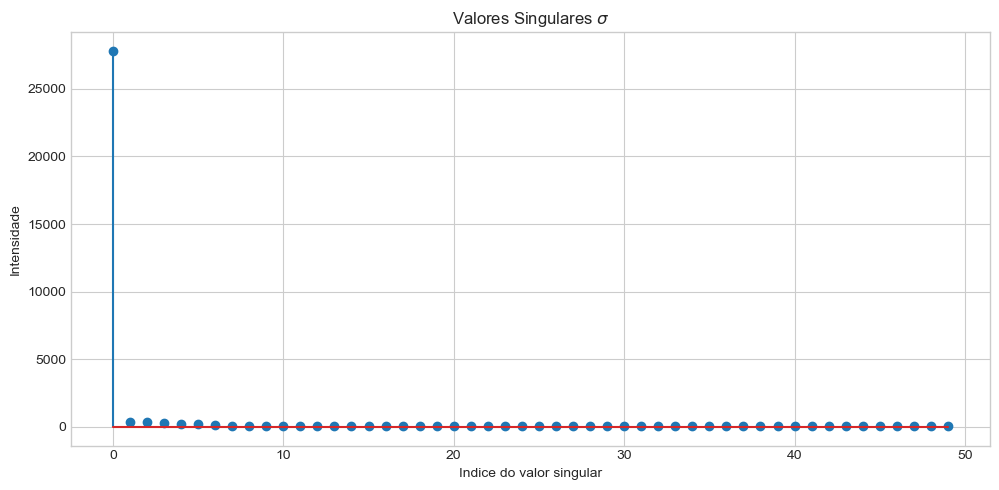

In [36]:
# Realizar a decomposição da matriz
U, S_array, VT = np.linalg.svd(H_m.X,full_matrices=False) #adiciono full_matrices=False para bater as dimensões

# Gerando o valor de S
S= np.diag(S_array)

print("Shape da Matriz Original X:", H_m.X.shape)
print("Shape de U:", U.shape)
print("Shape de S:", S.shape)
print("Shape de V^t:", VT.shape)

plt.figure(figsize=(10,5))
plt.title("Valores Singulares $\sigma$")
plt.xlabel("Indice do valor singular")
plt.ylabel("Intensidade")
plt.tight_layout()
plt.stem(S_array[0:50])

print("Primeiros 10 valores singulares:\n", S_array[0:10])

### Passo 3: Grouping (Agrupamento)
Particionamos o conjunto de índices $\{1, \dots, d\}$ em grupos disjuntos $I_1, I_2, \dots, I_m$ baseados na magnitude de $\sigma_i$ ou na frequência dos componentes:
$$X = X_{I_1} + X_{I_2} + \dots + X_{I_m}$$
Cada sub-matriz $X_{I}$ representa uma característica física (ex: $X_{Trend}, X_{Seasonal}, X_{Noise}$).

Tipos de grupos [exemplo]:
1. Variança
2. Pares Harmônicos ($\sigma_i \approx \sigma_j$)
3. Limiar de Variânça (Energia acumulada)
4. Matriz de Correlação (W-correlação)

In [37]:
# =====================================================================
# 1. IDENTIFICAÇÃO DE PARES HARMÔNICOS (CICLOS/SAZONALIDADE)
# =====================================================================
def find_harmonic_pairs(S_array: np.ndarray, tolerancia: float = 0.05) -> list:
    """
    Identifica componentes que devem ser agrupados juntos por representarem 
    a mesma frequência sazonal (pares harmônicos de seno/cosseno).
    
    Parâmetros:
    -----------
    S_array : np.ndarray
        Vetor 1D contendo os valores singulares.
    tolerancia : float, default=0.05
        Diferença relativa máxima para considerar dois valores como um par (ex: 5%).
        
    Retornos:
    ---------
    list de tuplas
        Lista contendo os pares de índices agrupados. Ex: [(1, 2), (4, 5)]
    """
    pares = []
    for i in range(len(S_array) - 1):
        # Cálculo da diferença relativa: |s_i - s_{i+1}| / s_i
        diff_relativa = abs(S_array[i] - S_array[i+1]) / S_array[i]
        
        if diff_relativa <= tolerancia:
            pares.append((i, i+1))
            
    return pares

# =====================================================================
# 2. LIMIAR DE VARIÂNCIA (ENCAPSULADO - SÓ RECEBE A SÉRIE Y)
# =====================================================================
def group_by_variance_threshold(S_array: np.ndarray, threshold_pct: float = 95.0):
    """
    Executa o SVD completo da série temporal e seleciona automaticamente 
    os componentes que somam uma determinada energia (variância).
    
    Parâmetros:
    -----------
    S_array = Valores de sigma em array
    threshold_pct : float, default=95.0
        Porcentagem alvo de variância para manter (ex: 95.0%).
        
    Retornos:
    ---------
    S_new : np.ndarray
        Array da mesma dimensão de S_array, mas com os valores descartados zerados.
    indices_mantidos : list
        Lista de índices selecionados pelo corte da variância.
    var_acumulada : np.ndarray
        Vetor com o percentual acumulado passo a passo.
    """
    # Garante que seja um array numpy
    S_array_new = np.asarray(S_array)
    
    # Agrupamento: Cálculo da energia/variância
    variancia = (S_array_new**2 / np.sum(S_array_new**2)) * 100
    var_acumulada = np.cumsum(variancia)
    
    # Encontra os índices necessários para ultrapassar o limite estabelecido
    idx_corte = np.argmax(var_acumulada >= threshold_pct)
    indices_mantidos = list(range(idx_corte + 1))

    # Cria um array de zeros com o mesmo tamanho de S_array
    S_array_new = np.zeros_like(S_array)
    
    # Copia apenas os valores singulares que foram mantidos
    S_array_new[:idx_corte + 1] = S_array[:idx_corte + 1]
    
    return S_array_new, indices_mantidos, var_acumulada

# =====================================================================
# 3. CORTE MANUAL POR NÚMERO DE COMPONENTES
# =====================================================================
def keep_n_components(S_array: np.ndarray, n_components: int):
    """
    Mantém apenas os 'n' primeiros valores singulares e descarta o restante.
    
    Parâmetros:
    -----------
    S_array : np.ndarray
        Vetor 1D contendo os valores singulares originais.
    n_components : int
        Número exato de componentes a serem mantidos (ex: 5).
        
    Retornos:
    ---------
    S_array_new : np.ndarray
        Array com os 'n' primeiros valores originais mantidos e o resto zerado.
    indices_mantidos : list
        Lista de índices selecionados para facilitar a plotagem.
    """
    # Cria um array de zeros com o mesmo tamanho do original
    S_array_new = np.zeros_like(S_array)
    
    # Copia apenas a quantidade de componentes solicitada
    S_array_new[:n_components] = S_array[:n_components]
    
    # Gera a lista de índices (0 até n_components - 1)
    indices_mantidos = list(range(n_components))
    
    return S_array_new, indices_mantidos
    

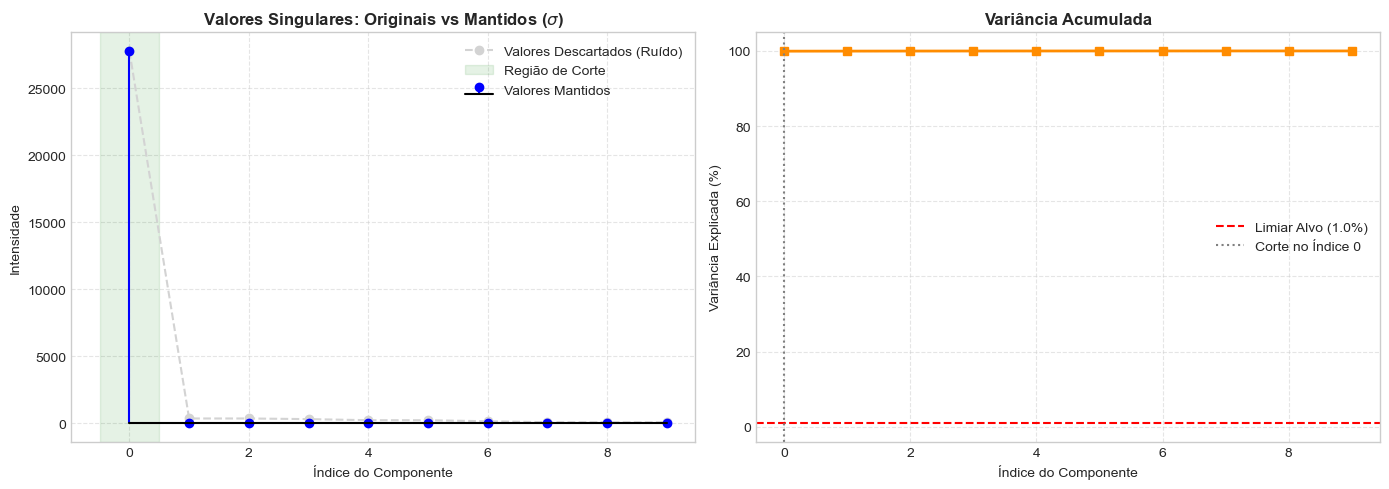

In [38]:
# 1. Definimos o limiar em uma variável para sincronizar a função e o gráfico
limiar = 1.0 # Mude este valor para testar cortes diferentes

# Executa a função e obtém os resultados
S_array_new, indices_mantidos, va_cum = group_by_variance_threshold(S_array, threshold_pct=limiar)

# Descobre onde o algoritmo fez o corte (o último índice mantido)
idx_corte = indices_mantidos[-1] if indices_mantidos else 0

# Define um zoom para o gráfico (mostra os mantidos + uma folga de 10 índices para contexto)
limite_visao = min(idx_corte + 10, len(S_array_new))

# 2. Cria uma figura com 1 linha e 2 colunas (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# GRÁFICO 1: Valores Originais vs Filtrados
# ==========================================
axes[0].set_title("Valores Singulares: Originais vs Mantidos ($\sigma$)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Índice do Componente")
axes[0].set_ylabel("Intensidade")

# ADIÇÃO: Plota os valores reais (S_array completo) em cinza tracejado como referência
axes[0].plot(range(limite_visao), S_array[:limite_visao], marker='o', color='lightgray', linestyle='--', label='Valores Descartados (Ruído)')

# Plota os valores filtrados (S_array_new) por cima usando o stem
# Os valores que foram zerados aparecerão no eixo 0
axes[0].stem(range(limite_visao), S_array_new[:limite_visao], basefmt='k-', linefmt='b-', markerfmt='bo', label='Valores Mantidos')

# Pinta o fundo de verde clarinho para destacar a região dos componentes preservados
axes[0].axvspan(-0.5, idx_corte + 0.5, color='green', alpha=0.1, label="Região de Corte")

axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# ==========================================
# GRÁFICO 2: Variância Acumulada
# ==========================================
axes[1].set_title("Variância Acumulada", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Índice do Componente")
axes[1].set_ylabel("Variância Explicada (%)")

# Plota a linha com marcadores para melhor visualização
axes[1].plot(range(limite_visao), va_cum[:limite_visao], marker='s', color='darkorange', linewidth=2)

# Linhas de referência sincronizadas com a variável `limiar`
axes[1].axhline(y=limiar, color='red', linestyle='--', linewidth=1.5, label=f'Limiar Alvo ({limiar}%)')
axes[1].axvline(x=idx_corte, color='gray', linestyle=':', linewidth=1.5, label=f'Corte no Índice {idx_corte}')

axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

# Ajusta o espaçamento para não sobrepor títulos e mostra o painel
plt.tight_layout()
plt.show()

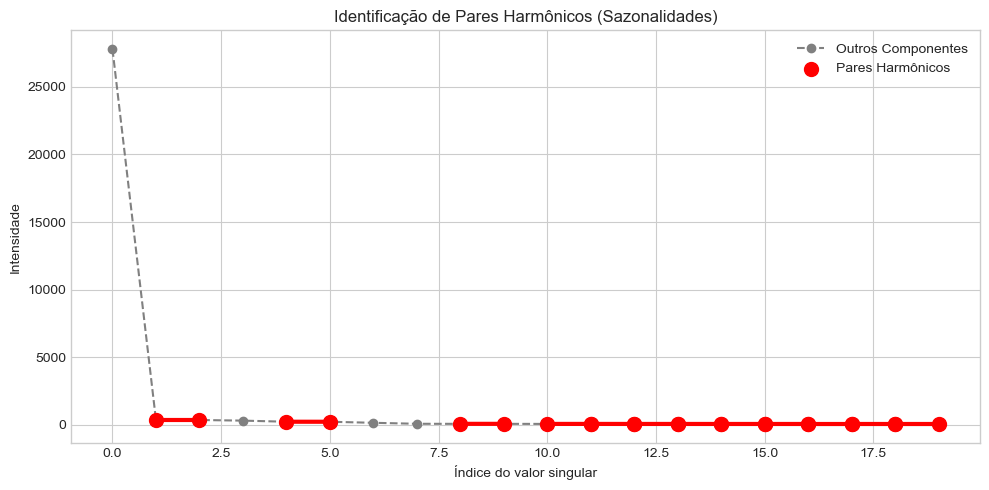

In [39]:
# =====================================================================
# EXEMPLO DE USO: IDENTIFICAÇÃO DE PARES HARMÔNICOS
# =====================================================================
# 1. Chamando a função (usando uma tolerância de 5%)
# Dica: Você pode passar o S_array original ou o S_array_new filtrado
pares_encontrados = find_harmonic_pairs(S_array, tolerancia=0.05)

#print(f"Pares harmônicos identificados: {pares_encontrados}")
# Saída esperada (exemplo): [(1, 2), (3, 4), (5, 6)]

# 2. Plotando o resultado
plt.figure(figsize=(10, 5))
plt.title("Identificação de Pares Harmônicos (Sazonalidades)")
plt.xlabel("Índice do valor singular")
plt.ylabel("Intensidade")

# Limitamos a visualização aos primeiros 20 componentes para facilitar a leitura do gráfico
limite_visao = 20 
indices_plot = range(limite_visao)

# Plota a linha base com todos os valores singulares em azul
plt.plot(indices_plot, S_array[:limite_visao], marker='o', linestyle='--', color='gray', label='Valores Singulares')

# Destaca os pares encontrados em vermelho
for par in pares_encontrados:
    idx1, idx2 = par
    
    # Garante que só vai tentar desenhar se o índice estiver dentro do limite de visão do gráfico
    if idx2 < limite_visao:
        # Desenha marcadores maiores e vermelhos para os pares
        plt.scatter([idx1, idx2], [S_array[idx1], S_array[idx2]], color='red', s=100, zorder=5)
        # Conecta o par com uma linha vermelha mais grossa
        plt.plot([idx1, idx2], [S_array[idx1], S_array[idx2]], color='red', linewidth=3, zorder=4)

# Ajuste fino da legenda e layout
plt.legend(["Outros Componentes", "Pares Harmônicos"], loc='upper right')
plt.tight_layout()
plt.show()

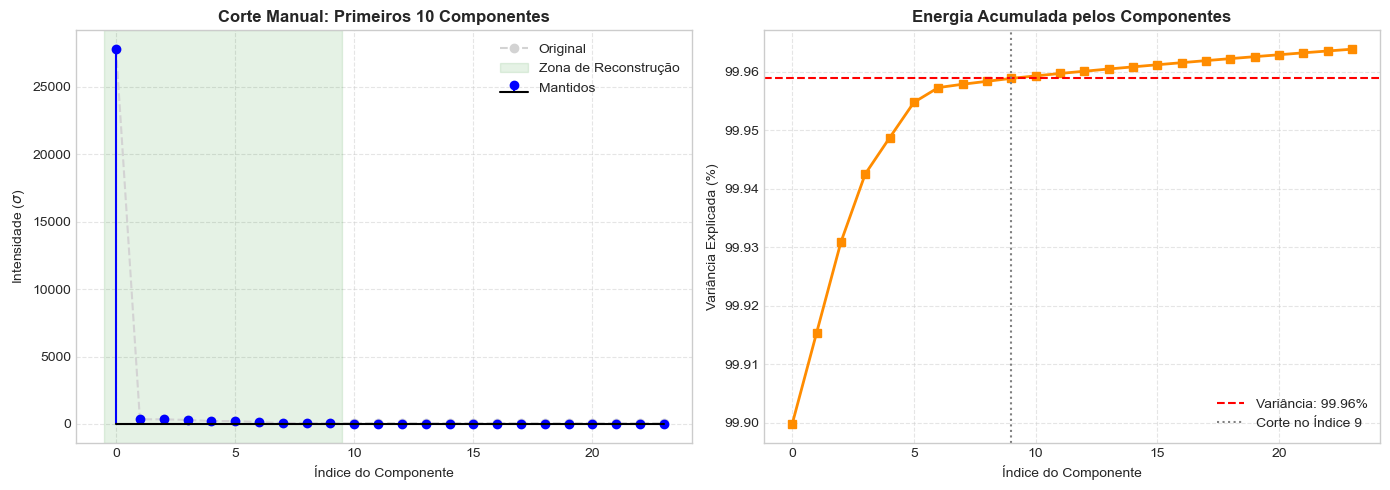

In [40]:
# 1. Configuração Manual
n_escolhido = 10 

# Executa a função de corte manual
S_array_new, indices_mantidos = keep_n_components(S_array, n_components=n_escolhido)

# Cálculo manual da variância acumulada (apenas para o gráfico)
variancia = (S_array**2 / np.sum(S_array**2)) * 100
va_cum = np.cumsum(variancia)

# Descobre o índice de corte e o valor da variância nesse ponto
idx_corte = indices_mantidos[-1]
var_alcancada = va_cum[idx_corte]

# Define um zoom para o gráfico
limite_visao = min(idx_corte + 15, len(S_array))

# 2. Cria a figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# GRÁFICO 1: Valores Originais vs Filtrados
# ==========================================
axes[0].set_title(f"Corte Manual: Primeiros {n_escolhido} Componentes", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Índice do Componente")
axes[0].set_ylabel("Intensidade ($\sigma$)")

# Referência em cinza
axes[0].plot(range(limite_visao), S_array[:limite_visao], marker='o', color='lightgray', linestyle='--', label='Original')
# Valores mantidos
axes[0].stem(range(limite_visao), S_array_new[:limite_visao], basefmt='k-', linefmt='b-', markerfmt='bo', label='Mantidos')

axes[0].axvspan(-0.5, idx_corte + 0.5, color='green', alpha=0.1, label="Zona de Reconstrução")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# ==========================================
# GRÁFICO 2: Variância Acumulada (Sincronizado)
# ==========================================
axes[1].set_title("Energia Acumulada pelos Componentes", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Índice do Componente")
axes[1].set_ylabel("Variância Explicada (%)")

# Plota a curva de variância
axes[1].plot(range(limite_visao), va_cum[:limite_visao], marker='s', color='darkorange', linewidth=2)

# Linhas de referência no ponto exato do seu corte manual
axes[1].axhline(y=var_alcancada, color='red', linestyle='--', linewidth=1.5, 
                label=f'Variância: {var_alcancada:.2f}%')
axes[1].axvline(x=idx_corte, color='gray', linestyle=':', linewidth=1.5, 
                label=f'Corte no Índice {idx_corte}')

axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Passo 4: Diagonal Averaging (Média Diagonal)
Para retornar ao domínio do tempo, transformamos cada matriz $X_{I}$ em uma série temporal $g$ de comprimento $N$. Para um elemento $x_{i,j}$ da matriz, a série resultante é a média das diagonais:
$$g_k = \text{média}(x_{i,j}) \text{ tal que } i+j = k+1$$


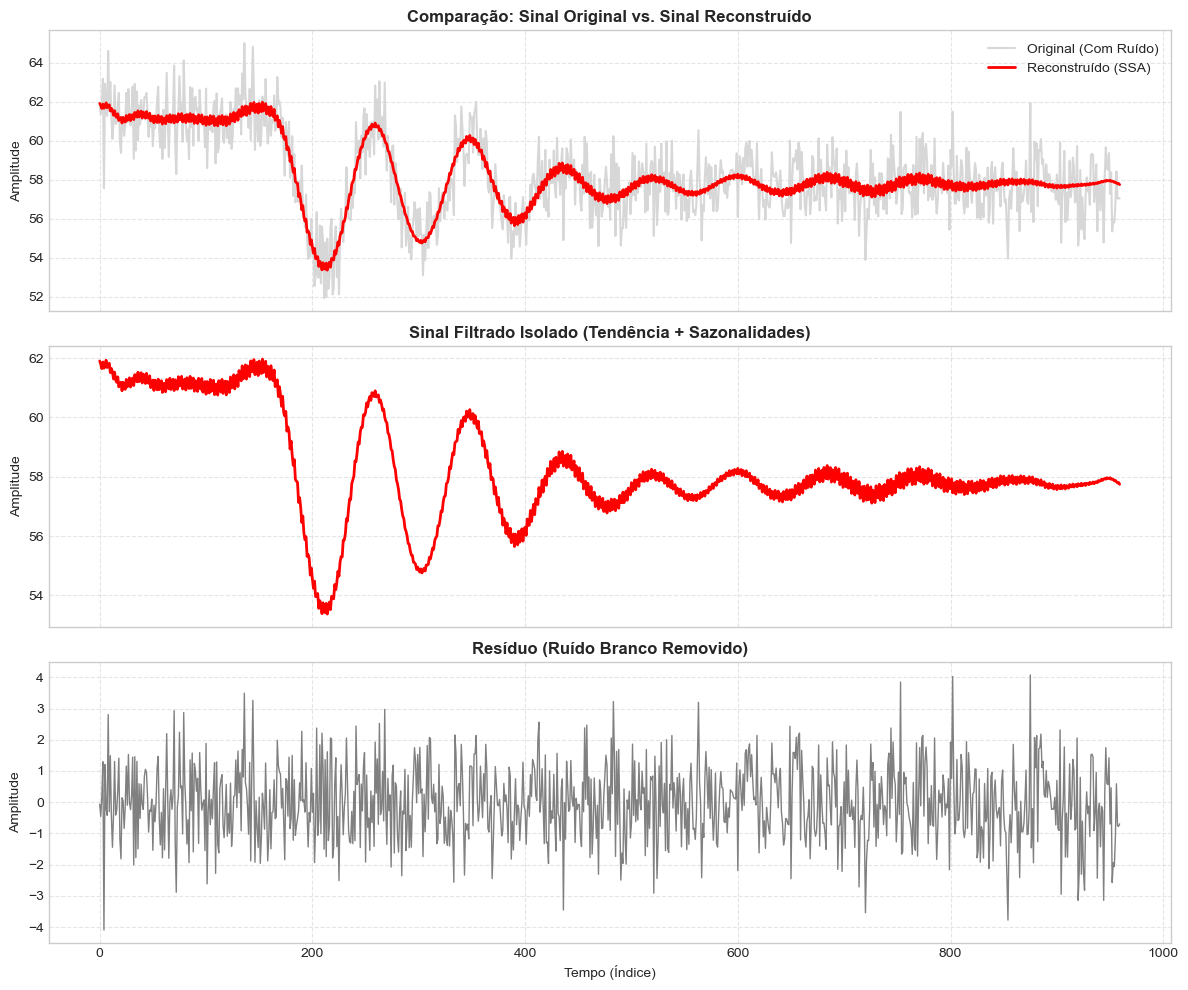

In [41]:
# =====================================================================
# 1. RECONSTRUÇÃO DA MATRIZ E DO SINAL
# =====================================================================
S_new = np.diag(S_array_new) #Aqui estou utilizando pela seleção dos valores

X_new = U @ S_new @ VT

y_new = H_m.reconstruct(X_new)

# Calcula o ruído removido (Sinal Original - Sinal Reconstruído)
# Nota: Assumindo que a variável original se chama 'serie'
residuo = serie - y_new 

# =====================================================================
# 2. VISUALIZAÇÃO DOS RESULTADOS (PAINEL COMPARATIVO)
# =====================================================================
# Cria uma figura com 3 gráficos empilhados compartilhando o eixo X
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# --- Gráfico 1: Sobreposição (Antes e Depois) ---
axes[0].set_title("Comparação: Sinal Original vs. Sinal Reconstruído", fontsize=12, fontweight='bold')
axes[0].plot(serie, label='Original (Com Ruído)', color='lightgray', alpha=0.9)
axes[0].plot(y_new, label='Reconstruído (SSA)', color='red', linewidth=2)
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 2: Apenas o Sinal Reconstruído ---
axes[1].set_title("Sinal Filtrado Isolado (Tendência + Sazonalidades)", fontsize=12, fontweight='bold')
axes[1].plot(y_new, color='red', linewidth=2)
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 3: O Resíduo (Ruído Removido) ---
axes[2].set_title("Resíduo (Ruído Branco Removido)", fontsize=12, fontweight='bold')
axes[2].plot(residuo, color='gray', linewidth=1)
axes[2].set_xlabel("Tempo (Índice)")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, linestyle='--', alpha=0.5)

# Ajusta o layout para não cortar os títulos
plt.tight_layout()
plt.show()

### Fluxo de Trabalho no Python
1. **Definir $L$**: Geralmente $L \approx N/2$ ou o período de sazonalidade.
2. **`np.linalg.svd`**: Obter os componentes.
3. **Análise do Scree Plot**: Plotar $\sigma_i$ para decidir o corte do ruído.
4. **Reconstrução**: Aplicar a média diagonal nas componentes escolhidas.

In [33]:
# Wraper Geral para essa análise 



## 1.3. Principal Componente Analysis (PLC)

## 1.4. Partial Last Squares (PLS)

## 2. Definição de Faltas

## 2.1. Estatística T²

## 2.2. Estatística Q